In [47]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded")

Libraries loaded


In [48]:
df = pd.read_csv('../data/UK_Accident.csv')
print(df.shape)
print(df.head())


(1504150, 33)
   Unnamed: 0 Accident_Index  Location_Easting_OSGR  Location_Northing_OSGR  \
0           0  200501BS00001               525680.0                178240.0   
1           1  200501BS00002               524170.0                181650.0   
2           2  200501BS00003               524520.0                182240.0   
3           3  200501BS00004               526900.0                177530.0   
4           4  200501BS00005               528060.0                179040.0   

   Longitude   Latitude  Police_Force  Accident_Severity  Number_of_Vehicles  \
0  -0.191170  51.489096             1                  2                   1   
1  -0.211708  51.520075             1                  3                   1   
2  -0.206458  51.525301             1                  3                   2   
3  -0.173862  51.482442             1                  3                   1   
4  -0.156618  51.495752             1                  3                   1   

   Number_of_Casualties  ...  

In [49]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (1504150, 33)

Columns: Index(['Unnamed: 0', 'Accident_Index', 'Location_Easting_OSGR',
       'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force',
       'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties',
       'Date', 'Day_of_Week', 'Time', 'Local_Authority_(District)',
       'Local_Authority_(Highway)', '1st_Road_Class', '1st_Road_Number',
       'Road_Type', 'Speed_limit', 'Junction_Control', '2nd_Road_Class',
       '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location', 'Year'],
      dtype='object')

Data types:
 Unnamed: 0                                       int64
Accident_Index                                  object
Location_Easting_OSGR     

In [50]:
# Get rid of unamed index column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Change date to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

#Get useful time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Years covered:", sorted(df['Year'].unique()))

Date range: 2005-01-01 00:00:00 to 2014-12-31 00:00:00
Years covered: [np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014)]


Handling missing values:

In [51]:
# Check missing before
print("Missing before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Drop rows where location is missing (can't be useful without it)
df.dropna(subset=['Longitude', 'Latitude'], inplace=True)

# Fill LSOA with Unknown (108k missing but column still useful)
df['LSOA_of_Accident_Location'] = df['LSOA_of_Accident_Location'].fillna('Unknown')

# Check missing after
print("\nMissing after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing before cleaning:
Location_Easting_OSGR                          101
Longitude                                      101
Time                                           117
Junction_Control                            602835
Pedestrian_Crossing-Human_Control               17
Pedestrian_Crossing-Physical_Facilities         34
Special_Conditions_at_Site                 1467568
Carriageway_Hazards                        1476900
LSOA_of_Accident_Location                   108238
dtype: int64

Missing after cleaning:
Time                                           117
Junction_Control                            602769
Pedestrian_Crossing-Human_Control               17
Pedestrian_Crossing-Physical_Facilities         33
Special_Conditions_at_Site                 1467471
Carriageway_Hazards                        1476802
dtype: int64


In [52]:
df['Special_Conditions_at_Site'] = df['Special_Conditions_at_Site'].fillna('None')
df['Carriageway_Hazards'] = df['Carriageway_Hazards'].fillna('None')
df['Junction_Control'] = df['Junction_Control'].fillna('Not at junction')
df['Pedestrian_Crossing-Human_Control'] = df['Pedestrian_Crossing-Human_Control'].fillna('None within 50 metres')
df['Pedestrian_Crossing-Physical_Facilities'] = df['Pedestrian_Crossing-Physical_Facilities'].fillna('No physical crossing within 50 meters')
df.dropna(subset=['Time'], inplace=True)

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


ACCIDENTS BY SEVERITY

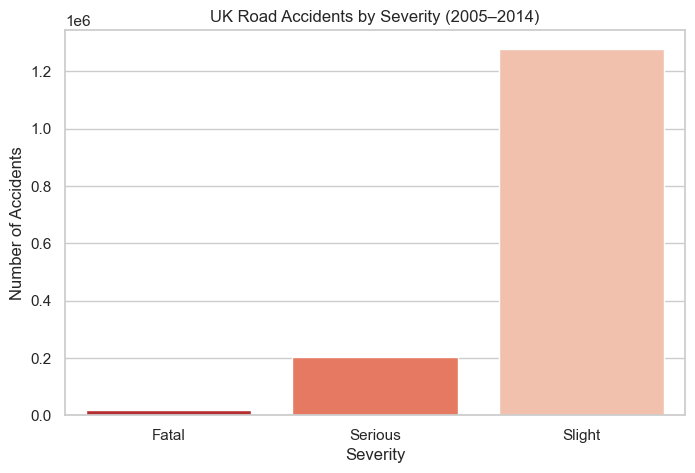

In [53]:
plt.figure(figsize=(8,5))
severity_counts = df['Accident_Severity'].value_counts().sort_index()
severity_labels = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
severity_counts.index = severity_counts.index.map(severity_labels)

sns.barplot(x=severity_counts.index, y=severity_counts.values, hue=severity_counts.index, palette='Reds_r', legend=False)
plt.title('UK Road Accidents by Severity (2005–2014)')
plt.ylabel('Number of Accidents')
plt.xlabel('Severity')
plt.show()

ACCIDENTS RECORDED BY TIME OF DAY:

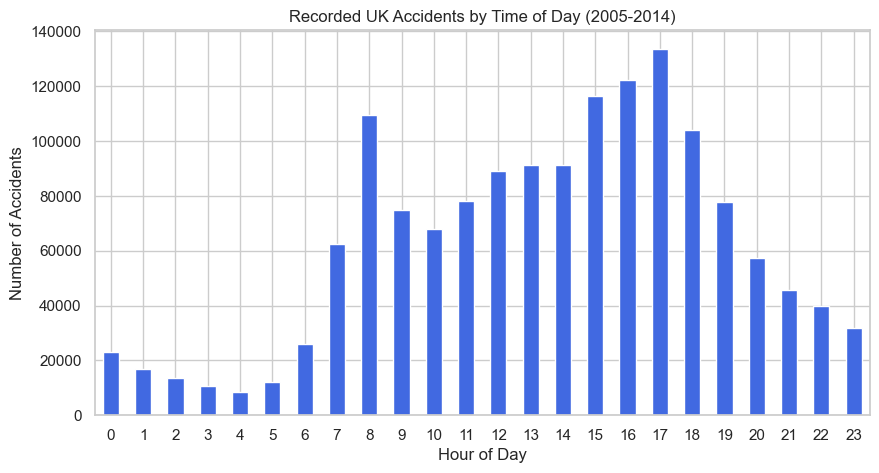

In [ ]:
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour

plt.figure(figsize=(10, 5))
df['Hour'].value_counts().sort_index().plot(kind='bar', color='royalblue')
plt.title('Recorded UK Accidents by Time of Day (2005-2014)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.show()

ACCIDENTS BY WEATHER CONDITIONS

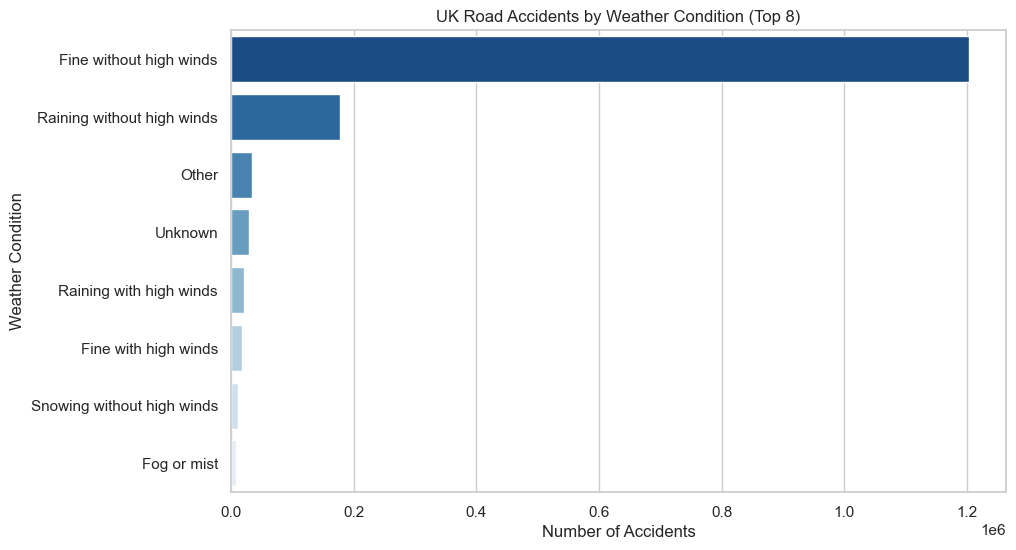

In [55]:
plt.figure(figsize=(10,6))
weather_counts = df['Weather_Conditions'].value_counts().head(8)

sns.barplot(y=weather_counts.index, x=weather_counts.values, hue=weather_counts.index, palette='Blues_r', legend=False)
plt.title('UK Road Accidents by Weather Condition (Top 8)')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Condition')
plt.show()

- Based on provided data, Most accidents occur during peak work commuting and end of school hours (8am and 4-6pm).

- Severity of accidents are minor/slight, could occur due to slow, busy traffic conditions. A strong link to commuter traffic volume

- Unexpectedly more accidents occur in good weather Conditions
